In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/sentiment.csv")

In [4]:
df.shape

(50000, 2)

In [5]:
df.head

<bound method NDFrame.head of                                                   review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative
49997  I am a Catholic taught in parochial elementary...  negative
49998  I'm going to have to disagree with the previou...  negative
49999  No one expects the Star Trek movies to be high...  negative

[50000 rows x 2 columns]>

In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Text(0.5, 1.0, 'Sentiment Distribution')

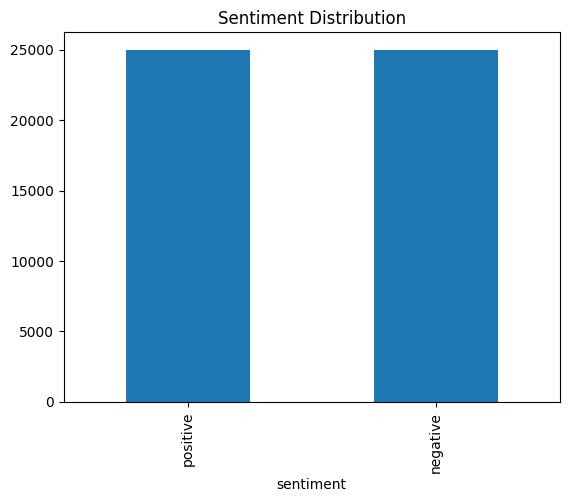

In [8]:
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")


In [9]:
df["review_length"]=df["review"].apply(len)

In [10]:
df["review_length"].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

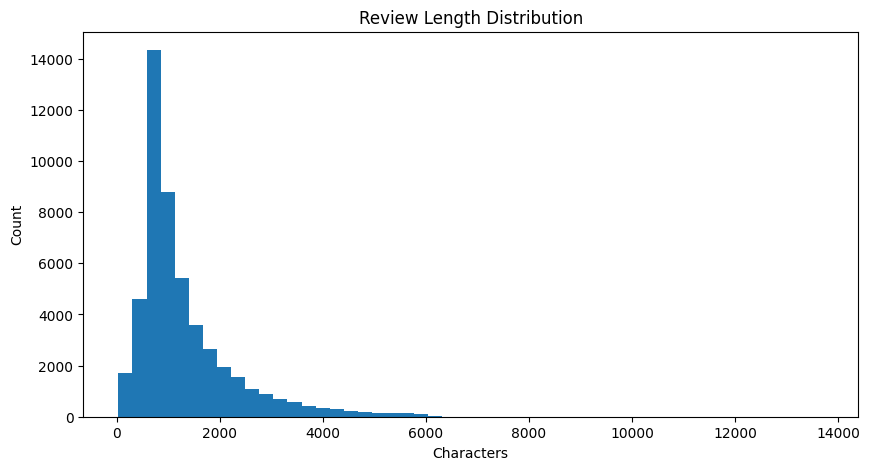

In [11]:
#histogram of review lengths

plt.figure(figsize=(10,5))
plt.hist(df["review_length"], bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

In [12]:
df["review"].iloc[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [13]:
df[df["sentiment"]=="positive"]["review"].iloc[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [14]:
df[df["sentiment"]=="negative"]["review"].iloc[0]

"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."

In [15]:
df.shape

(50000, 3)

In [16]:
#cleaning time 
import re

Raw Review
↓
Remove HTML
↓
Lowercase
↓
Remove URLs
↓
Remove punctuation
↓
Remove extra spaces
↓
Return Clean Text

In [17]:
def clean_text(text):
    #convert to lowercase

    text = text.lower()

    #remove the HTML tags

    text=re.sub(r"<.*?>", "", text)

    #remove the urls

    text=re.sub(r"http\S+\www\S+", "", text)

    #remove the punctuation and special characters

    text=re.sub(r"[^a-zA-Z\s]","",text)

    #remove the extra space

    text = re.sub(r"\s+"," ",text).strip()

    return text

In [18]:
sample_review = df["review"].iloc[0]

In [19]:
print("Og")

Og


In [20]:
print(sample_review)

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [21]:
sample_review = df["review"].iloc[0]

print("ORIGINAL REVIEW:")
print(sample_review)

print("\n" + "="*100 + "\n")

print("CLEANED REVIEW:")
print(clean_text(sample_review))

ORIGINAL REVIEW:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [22]:
df["cleaned_review"] = df["review"].apply(clean_text)

In [23]:
print("Original Review")
print(df["review"].iloc[5])

print("\n" + "="*100 + "\n")

print("Cleaned")
print(df["cleaned_review"].iloc[5])

Original Review
Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it's not preachy or boring. It just never gets old, despite my having seen it some 15 or more times in the last 25 years. Paul Lukas' performance brings tears to my eyes, and Bette Davis, in one of her very few truly sympathetic roles, is a delight. The kids are, as grandma says, more like "dressed-up midgets" than children, but that only makes them more fun to watch. And the mother's slow awakening to what's happening in the world and under her own roof is believable and startling. If I had a dozen thumbs, they'd all be "up" for this movie.


Cleaned
probably my alltime favorite movie a story of selflessness sacrifice and dedication to a noble cause but its not preachy or boring it just never gets old despite my having seen it some or more times in the last years paul lukas performance brings tears to my eyes and bette davis in one of her very few truly sympathe

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

In [26]:
X = vectorizer.fit_transform(df["cleaned_review"])

In [27]:
X.shape

(50000, 10000)

In [28]:
from sklearn.preprocessing import LabelEncoder

In [29]:
encoder = LabelEncoder()
y=encoder.fit_transform(df["sentiment"])

In [30]:
print(y[:10])

[1 1 1 0 1 1 1 0 0 1]


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify=y)

In [33]:
print(X_train.shape)

(40000, 10000)


In [34]:
print(X_test.shape)

(10000, 10000)


In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
lr_model = LogisticRegression(max_iter=10000)

In [37]:
lr_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [38]:
y_pred = lr_model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [40]:
accuracy = accuracy_score(y_test, y_pred)

In [41]:
print("Accuracy", accuracy)

Accuracy 0.8994


In [42]:
cm = confusion_matrix(y_test,y_pred)

In [43]:
print(cm)

[[4453  547]
 [ 459 4541]]


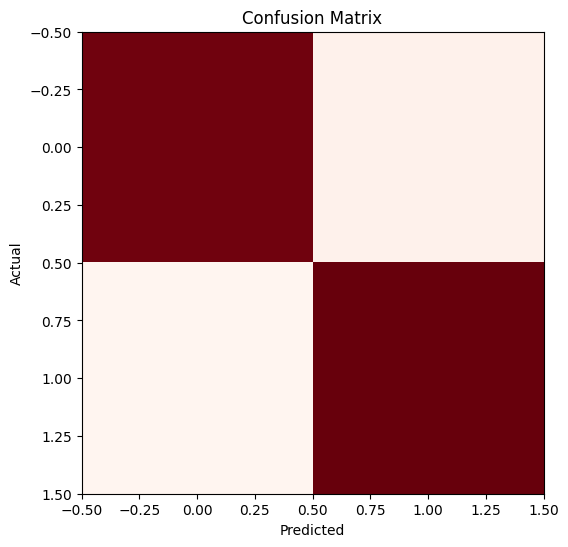

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap=plt.cm.Reds)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [45]:
my_review = """Well the movie was mid and the acting was trash. something i wouldn ot recommend to anyone"""

In [46]:
cleaned = clean_text(my_review)

In [47]:
review_vector = vectorizer.transform([cleaned])

In [48]:
prediction = lr_model.predict(review_vector)

print(prediction)

[0]


In [49]:
print(encoder.inverse_transform(prediction))

['negative']


In [50]:
probabilities = lr_model.predict_proba(review_vector)

print(probabilities)

[[0.64502082 0.35497918]]


In [51]:
print("mid" in vectorizer.vocabulary_)
print("trash" in vectorizer.vocabulary_)
print("recommend" in vectorizer.vocabulary_)

True
True
True


In [52]:
def predict_sentiment(review):

    cleaned = clean_text(review)

    vector = vectorizer.transform([cleaned])

    prediction = lr_model.predict(vector)[0]

    probabilities = lr_model.predict_proba(vector)[0]

    sentiment = encoder.inverse_transform([prediction])[0]

    return {
        "sentiment": sentiment,
        "confidence": float(max(probabilities)),
        "negative_probability": float(probabilities[0]),
        "positive_probability": float(probabilities[1])
    }

In [53]:
predict_sentiment(
    "This movie was amazing. One of the best films ever."
)

{'sentiment': 'positive',
 'confidence': 0.9781372503508754,
 'negative_probability': 0.021862749649124602,
 'positive_probability': 0.9781372503508754}

In [55]:
predict_sentiment(
    "Well the movie was mid and the acting was trash. something i wouldn ot recommend to anyone"
)

{'sentiment': 'negative',
 'confidence': 0.6450208194731146,
 'negative_probability': 0.6450208194731146,
 'positive_probability': 0.35497918052688543}